# Dataset: AB_NYC_2019

## Author: Emmanuel Aregbesola
## Date: March 2026

In [1]:
# import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# laod in the clean dataset

df = pd.read_csv('airbnb_cleaned.csv')

# 1. Basic Inspection

In this section, we will confirm the validity of the cleaned dataset. To do that, we will do the following;

1. Shape.
2. Column Names.
3. Data types.
4. Summary statistics.
5. Null values.

In [3]:
# validate the shape of the dataset

df.shape

(48768, 16)

In [4]:
# validate the column names

df.columns.to_list()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [5]:
# validate the data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48768 entries, 0 to 48767
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48768 non-null  int64  
 1   name                            48768 non-null  object 
 2   host_id                         48768 non-null  int64  
 3   host_name                       48768 non-null  object 
 4   neighbourhood_group             48768 non-null  object 
 5   neighbourhood                   48768 non-null  object 
 6   latitude                        48768 non-null  float64
 7   longitude                       48768 non-null  float64
 8   room_type                       48768 non-null  object 
 9   price                           48768 non-null  int64  
 10  minimum_nights                  48768 non-null  int64  
 11  number_of_reviews               48768 non-null  int64  
 12  last_review                     

In [6]:
# validate the null values present

df.isna().sum()

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       9935
reviews_per_month                 9935
calculated_host_listings_count       0
availability_365                     0
dtype: int64

In [7]:
# validate the summary statistics

df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.876800e+04,4.876800e+04,48768.000000,48768.000000,48768.000000,48768.000000,48768.000000,38833.000000,48768.000000,48768.000000
mean,1.900155e+07,6.750893e+07,40.728939,-73.952182,152.647556,7.006049,23.327346,1.373128,7.021448,112.485277
std,1.098377e+07,7.854996e+07,0.054565,0.046137,239.966651,20.519770,44.589808,1.680391,32.530641,131.455071
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,10.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.458954e+06,7.798076e+06,40.690027,-73.983072,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.965461e+07,3.072157e+07,40.723050,-73.955660,105.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.913342e+07,1.074344e+08,40.763130,-73.936287,175.000000,5.000000,24.000000,2.020000,2.000000,226.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [8]:
# convert to right datatype

df['last_review'] = pd.to_datetime(df['last_review'])
df['id'] = df['id'].astype(str)
df['host_id'] = df['host_id'].astype(str)

In [9]:
# validate change in datatype

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48768 entries, 0 to 48767
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48768 non-null  object        
 1   name                            48768 non-null  object        
 2   host_id                         48768 non-null  object        
 3   host_name                       48768 non-null  object        
 4   neighbourhood_group             48768 non-null  object        
 5   neighbourhood                   48768 non-null  object        
 6   latitude                        48768 non-null  float64       
 7   longitude                       48768 non-null  float64       
 8   room_type                       48768 non-null  object        
 9   price                           48768 non-null  int64         
 10  minimum_nights                  48768 non-null  int64         
 11  nu

## Summary of basic inspection

Loaded the cleaned dataset and cross-checked shape, columns, null values, and data types 
against the cleaning notebook. Everything checks out as expected.

Two dtype corrections were made upon loading:
- `last_review` — converted back to datetime (CSV format does not preserve datetime, reverts to object on save)
- `id` and `host_id` — converted from int to object since they are identifiers, not numeric columns

# 2. Explorative Data Analysis

### 2.1. Q1: What is the distribution of price across listings?

In [10]:
# Get the percentile for the prices

print(df['price'].quantile(0.95))
print(df['price'].quantile(0.99))
print(df['price'].max())

355.0
799.0
10000


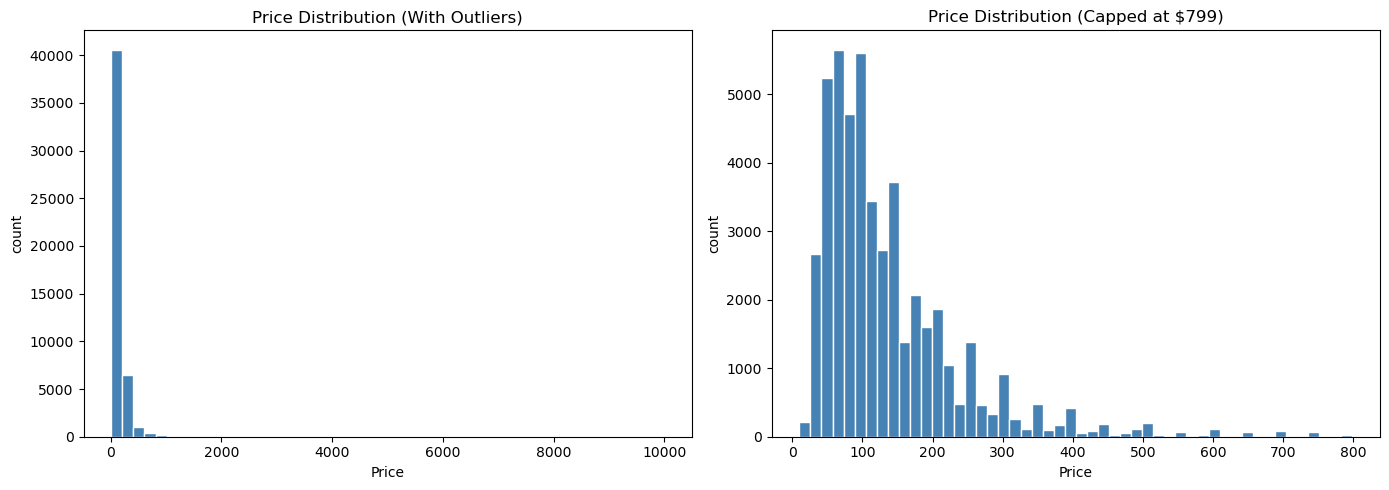

In [28]:
# plot the distribution graph for prices with and without outliers

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
ax[0].set_title('Price Distribution (With Outliers)')
ax[0].set_xlabel('Price')
ax[0].set_ylabel('count')

filtered = df[df['price'] <= 799]
ax[1].hist(filtered['price'], bins=50, color='steelblue', edgecolor='white')
ax[1].set_title('Price Distribution (Capped at $799)')
ax[1].set_xlabel('Price')
ax[1].set_ylabel('count')

plt.tight_layout()
plt.show()

In [15]:
# Get the mean and median

print(f"Mean: {df['price'].mean()}")
print(f"Median: {df['price'].median()}")

Mean: 152.6475557742782
Median: 105.0


In [27]:
# filter out the outliers

df[df['price'] > 799][['name', 'room_type', 'neighbourhood_group', 
                         'price', 'number_of_reviews', 'availability_365']].sort_values('price', ascending=False).head(50)

,name,room_type,neighbourhood_group,price,number_of_reviews,availability_365
9144,Furnished room in Astoria apartment,Private room,Queens,10000,2,0
17678,Luxury 1 bedroom apt. -stunning Manhattan views,Entire home/apt,Brooklyn,10000,5,0
29174,1-BR Lincoln Center,Entire home/apt,Manhattan,10000,0,83
12335,"Quiet, Clean, Lit @ LES & Chinatown",Private room,Manhattan,9999,6,83
6527,Spanish Harlem Apt,Entire home/apt,Manhattan,9999,1,0
40349,2br - The Heart of NYC: Manhattans Lower East ...,Entire home/apt,Manhattan,9999,0,365
30202,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Entire home/apt,Manhattan,8500,2,251
4376,Film Location,Entire home/apt,Brooklyn,8000,1,365
29596,East 72nd Townhouse by (Hidden by Airbnb),Entire home/apt,Manhattan,7703,0,146
45559,Gem of east Flatbush,Private room,Brooklyn,7500,8,179


## Findings

The price distribution is heavily right skewed — most listing prices cluster between `$50` and `$150`, 
with a long tail of high-end listings stretching to `$10,000`. 

The mean (`$152.65`) is pulled upward by luxury outliers, making the median (`$105.00`) a more 
representative measure of a typical NYC Airbnb listing price.

Listings above `$799` (99th percentile) were inspected and confirmed legitimate — most have 
reviews and represent the luxury segment of the market.

=====================================================================================================================

### 2.2. Q2: Is there a relationship between price and number of reviews?

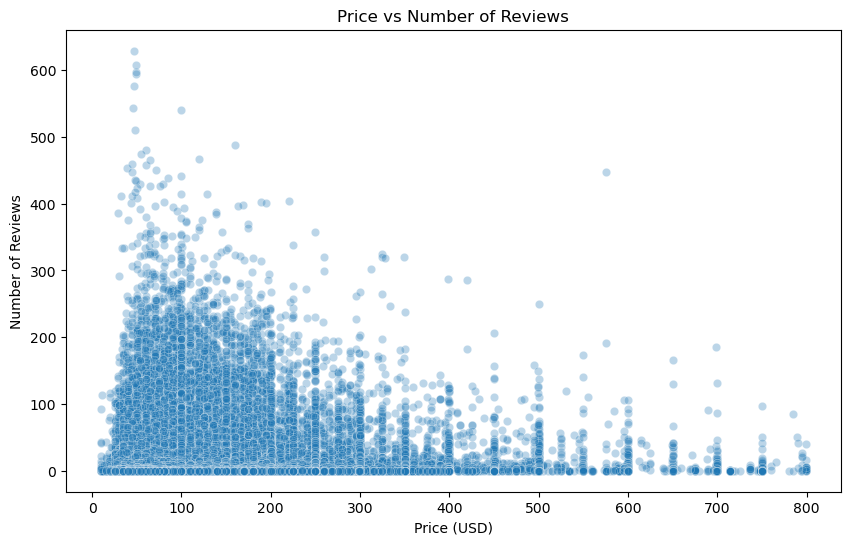

In [35]:
filtered = df[df['price'] <= 799]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=filtered, x='price', y='number_of_reviews', alpha=0.3)
plt.title('Price vs Number of Reviews')
plt.xlabel('Price (USD)')
plt.ylabel('Number of Reviews')

plt.show()

In [30]:
# check for correlation

print(filtered[['price', 'number_of_reviews']].corr())

                      price  number_of_reviews
price              1.000000          -0.055277
number_of_reviews -0.055277           1.000000


In [31]:
# check for correlation when number_of_reviews = 0

filtered_reviews = filtered[filtered['number_of_reviews'] > 0]
print(filtered_reviews[['price', 'number_of_reviews']].corr())

                      price  number_of_reviews
price              1.000000          -0.040114
number_of_reviews -0.040114           1.000000


## Findings

The scatter plot suggests higher priced listings tend to have fewer reviews. However, 
the Pearson correlation coefficient of -0.05 indicates almost no linear relationship 
between price and number of reviews.

The visual pattern is largely explained by density — the dataset has significantly more 
low-priced listings than high-priced ones, making the lower price range appear more active.

**Secondary check:** Removing listings with zero reviews returned a correlation of -0.04 — 
virtually identical to the full dataset result of -0.05. This confirms that price and number 
of reviews have no meaningful linear relationship in this dataset.